In [137]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [138]:
# Load libraries
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import string
import numpy as np
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

In [139]:
# Load raw data
pre_df = pd.read_csv("/content/drive/MyDrive/Pre Thriving Workshop Feedback.txt", sep="\t")
post_df = pd.read_csv("/content/drive/MyDrive/Post Thriving workshop feedback.txt", sep="\t")

# Combine responses into one document per student
def combine_responses(row, exclude_cols):
    return " ".join([str(row[col]) for col in row.index if col not in exclude_cols and pd.notnull(row[col])])

# Process pre-workshop feedback
pre_docs = []
for i, row in pre_df.iterrows():
    text = combine_responses(row, exclude_cols=["Q5", "Q6"])  # exclude optional questions
    pre_docs.append({
        "DocID": f"Pre{i+1}",
        "Label": "Pre",
        "Text": re.sub(r'\s+', ' ', text.strip())
    })

# Process post-workshop feedback
post_docs = []
for i, row in post_df.iterrows():
    text = combine_responses(row, exclude_cols=["Who is your assigned success advisor?"])
    post_docs.append({
        "DocID": f"Post{i+1}",
        "Label": "Post",
        "Text": re.sub(r'\s+', ' ', text.strip())
    })

# Combine datasets to export
combined_df = pd.DataFrame(pre_docs + post_docs)
combined_df.to_csv("/content/thriving_workshop_corpus.csv", index=False)



In [140]:
# Load combined data
df = pd.read_csv("/content/thriving_workshop_corpus.csv")
texts = df["Text"].astype(str)
labels = df["Label"]

In [141]:
# All text to evaluate word frequency
all_text = " ".join(df['Text'].dropna().astype(str)).lower()
all_text = re.sub(f"[{re.escape(string.punctuation)}]", "", all_text)
tokens = all_text.split()

# Count word frequencies
word_freq = Counter(tokens)

# Top 50 most common words
top_words = word_freq.most_common(50)
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])


print(top_words_df)


        Word  Frequency
0          i         31
1         no         22
2         to         15
3        yes         12
4       mind         10
5        the         10
6       have          9
7         it          9
8         on          8
9       more          7
10        of          6
11       and          6
12        do          6
13         a          5
14   mapping          5
15      like          5
16        is          5
17       for          5
18      time          5
19  semester          4
20       not          4
21      want          4
22      this          4
23        me          4
24       map          4
25      none          4
26     maybe          4
27     heard          3
28      used          3
29    before          3
30      plan          3
31        my          3
32       out          3
33       day          3
34       but          3
35   because          3
36       you          2
37     about          2
38        or          2
39       why          2
40        in    

In [142]:
# Base stopwords from sklearn
default_stopwords = set(ENGLISH_STOP_WORDS)

# Custom stopwords based on top word inspection
custom_stopwords = {
    'workshop', 'session', 'advisor', 'ecs', 'student', 'students', 'help', 'support', 'activity',
    'think', 'learned', 'something', 'things', 'also'
}

# Combine both sets
combined_stopwords = default_stopwords.union(custom_stopwords)

# Preview a sample of the final stopword list
stopwords_preview = list(combined_stopwords)[:50]
stopwords_df = pd.DataFrame(stopwords_preview, columns=['Sample Stopwords'])

print(stopwords_df)

   Sample Stopwords
0                 i
1             empty
2                at
3               now
4              side
5               six
6              none
7              name
8             never
9              most
10           toward
11             thus
12               be
13              any
14            fifty
15           detail
16          advisor
17            these
18           around
19               re
20             very
21             cant
22             done
23            among
24         describe
25               on
26              are
27              the
28         yourself
29          serious
30               he
31          learned
32            third
33              two
34        somewhere
35               an
36               is
37              top
38          amongst
39          wherein
40            above
41        otherwise
42          several
43             last
44              own
45         together
46            front
47              get
48        hereafter


In [143]:
# Function to clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in combined_stopwords]
    return " ".join(tokens)

df['Cleaned_Text'] = df['Text'].dropna().apply(clean_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


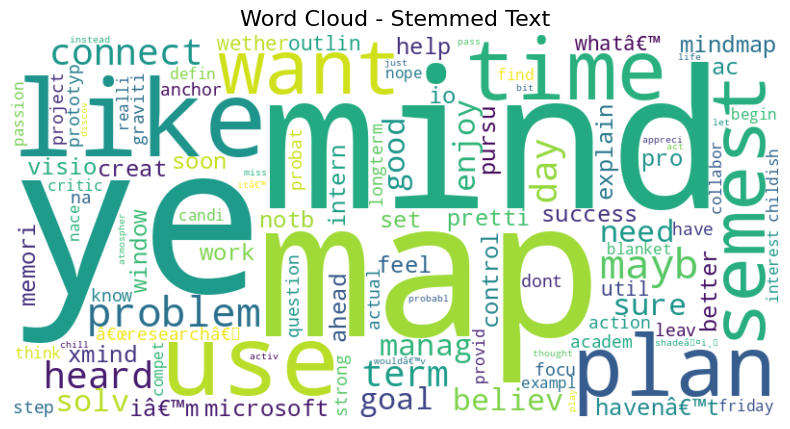

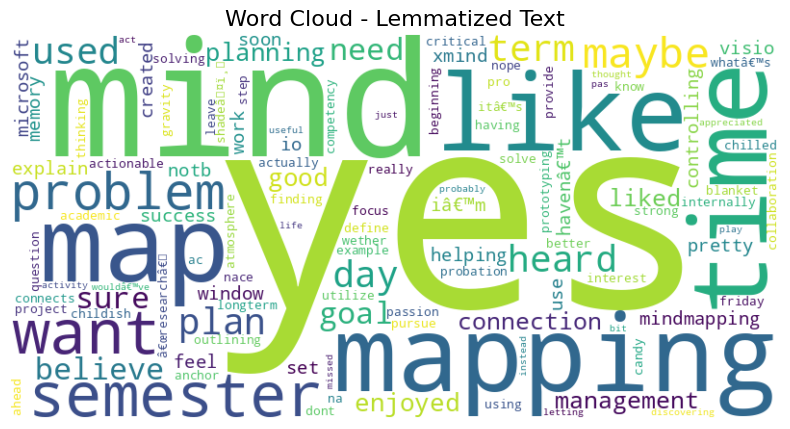

In [144]:
# Which works better with my data? Stemmer vs Lemmatizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Apply Porter Stemmer
stemmer = PorterStemmer()
df['Stemmed_Text'] = df['Cleaned_Text'].apply(lambda text: " ".join([stemmer.stem(word) for word in text.split()]))

# Apply WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()
df['Lemmatized_Text'] = df['Cleaned_Text'].apply(lambda text: " ".join([lemmatizer.lemmatize(word) for word in text.split()]))

# Create frequency counters
stemmed_word_freq = Counter(" ".join(df['Stemmed_Text']).split())
lemmatized_word_freq = Counter(" ".join(df['Lemmatized_Text']).split())

# Create WordClouds
def generate_wordcloud(freq_dict, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Generate both word clouds
generate_wordcloud(stemmed_word_freq, "Word Cloud - Stemmed Text")
generate_wordcloud(lemmatized_word_freq, "Word Cloud - Lemmatized Text")

# Prepare top words as dataframes for download/view
top_stemmed = pd.DataFrame(stemmed_word_freq.most_common(30), columns=["Stemmed Word", "Frequency"])
top_lemmatized = pd.DataFrame(lemmatized_word_freq.most_common(30), columns=["Lemmatized Word", "Frequency"])

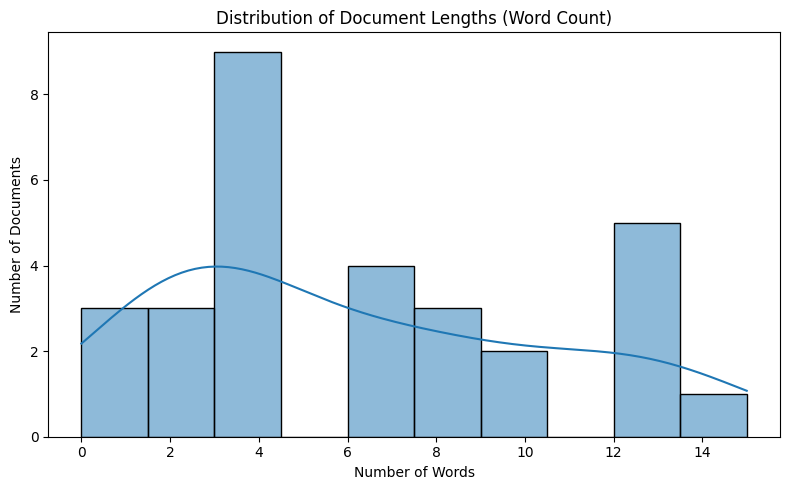

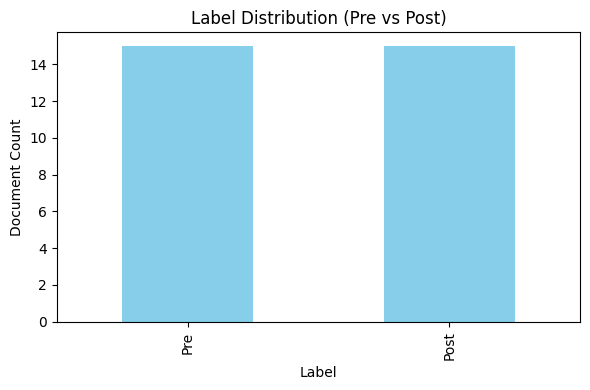

/tmp/ipython-input-145-2451532823.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_words.values()), y=list(top_words.keys()), palette="viridis")


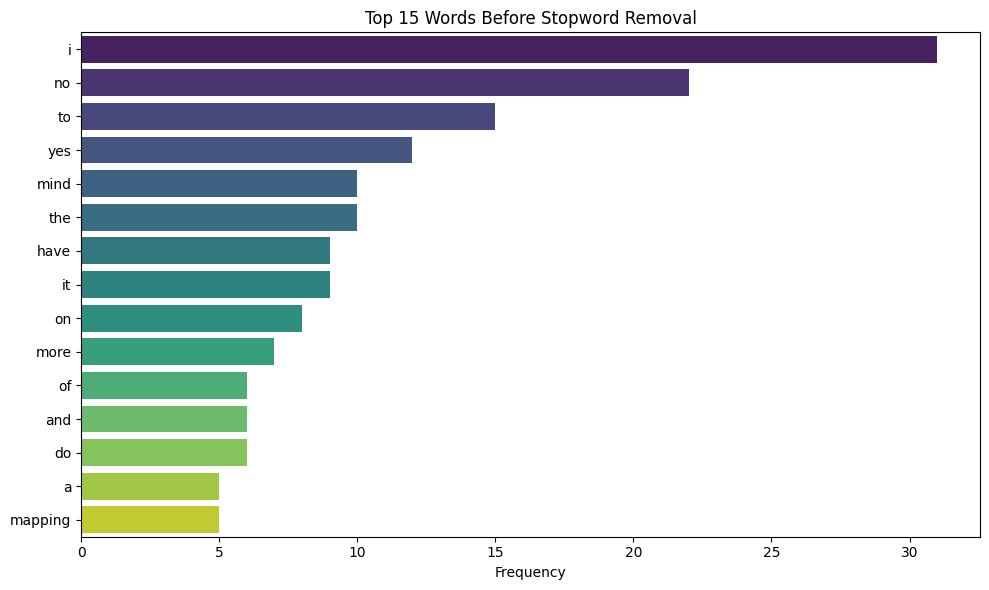

/tmp/ipython-input-145-2451532823.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(filtered_top_words.values()), y=list(filtered_top_words.keys()), palette="magma")


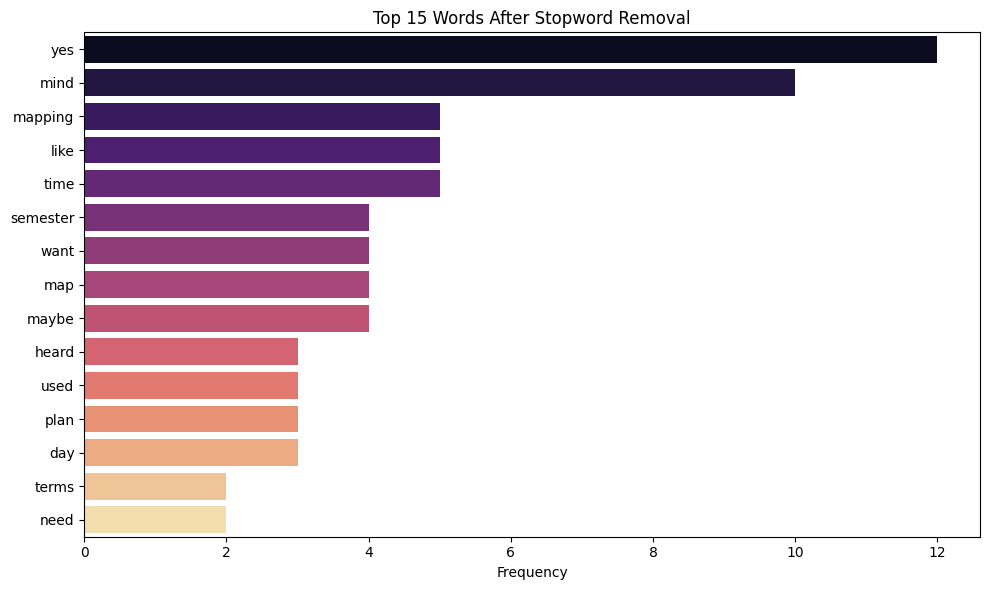

In [145]:
# Calculate document length
df['Doc_Length'] = df['Cleaned_Text'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)

# Calculate label counts
label_counts = df['Label'].value_counts()

# Calculate filtered frequency
all_cleaned_text = " ".join(df['Cleaned_Text'].dropna()).split()
filtered_freq = Counter(all_cleaned_text)

# Define the directory path
plot_dir = "/content/drive/MyDrive/plots"

if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

plt.figure(figsize=(8, 5))
sns.histplot(df['Doc_Length'], bins=10, kde=True)
plt.title("Distribution of Document Lengths (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.tight_layout()
doc_len_path = os.path.join(plot_dir, "doc_length_distribution.png")
plt.savefig(doc_len_path)
plt.show()

# Label Distribution
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color='skyblue')
plt.title("Label Distribution (Pre vs Post)")
plt.xlabel("Label")
plt.ylabel("Document Count")
plt.tight_layout()
label_dist_path = os.path.join(plot_dir, "label_distribution.png")
plt.savefig(label_dist_path)
plt.show()

# Top 15 words before and after stopword filtering
all_text = " ".join(df['Text'].dropna().astype(str)).lower()
all_text = re.sub(f"[{re.escape(string.punctuation)}]", "", all_text)
tokens = all_text.split()
word_freq = Counter(tokens)


top_words = dict(word_freq.most_common(15))
filtered_top_words = dict(filtered_freq.most_common(15))

# Top Words Before Stopword Removal
plt.figure(figsize=(10, 6))
sns.barplot(x=list(top_words.values()), y=list(top_words.keys()), palette="viridis")
plt.title("Top 15 Words Before Stopword Removal")
plt.xlabel("Frequency")
plt.tight_layout()
before_sw_path = os.path.join(plot_dir, "top_words_before_stopwords.png")
plt.savefig(before_sw_path)
plt.show()

# Top Words After Stopword Removal
plt.figure(figsize=(10, 6))
sns.barplot(x=list(filtered_top_words.values()), y=list(filtered_top_words.keys()), palette="magma")
plt.title("Top 15 Words After Stopword Removal")
plt.xlabel("Frequency")
plt.tight_layout()
after_sw_path = os.path.join(plot_dir, "top_words_after_stopwords.png")
plt.savefig(after_sw_path)
plt.show()

In [146]:
# Vectorize using TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=1000)
X = vectorizer.fit_transform(df["Cleaned_Text"])

In [147]:
# Normalize and apply KMeans
X_normalized = normalize(X)
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_normalized)



Vocabulary Size: 271
Sparsity: 4.12%


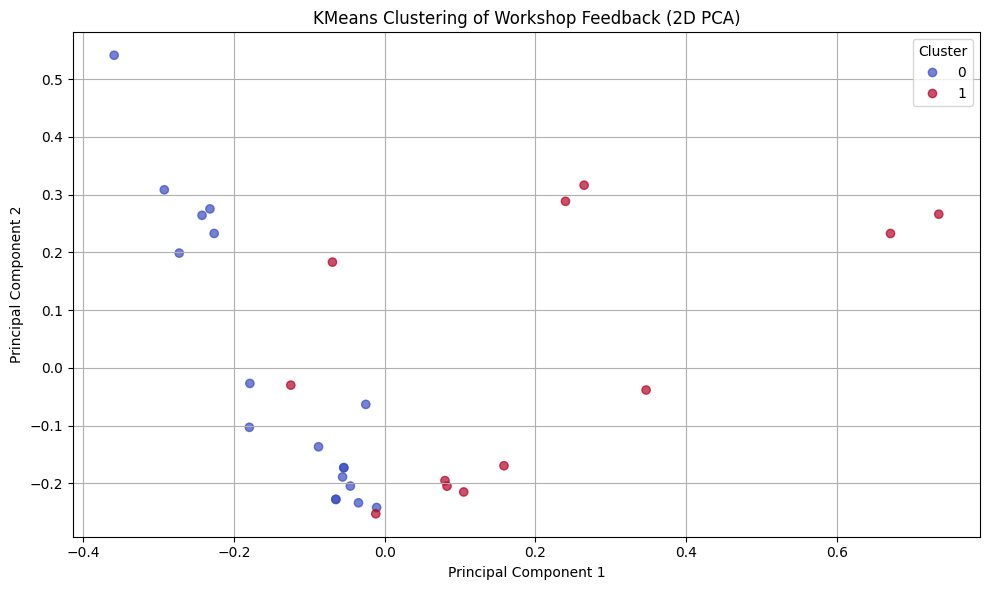

In [148]:
# Dimensionality reduction for plotting
X_pca = PCA(n_components=2).fit_transform(X_normalized.toarray())

# Plot the clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap='coolwarm', alpha=0.7)
plt.title("KMeans Clustering of Workshop Feedback (2D PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.savefig("/content/kmeans_clusters_visualization.png")

# Additional reporting
print(f"Vocabulary Size: {len(vectorizer.vocabulary_)}")
print(f"Sparsity: {100.0 * (X.nnz / (X.shape[0] * X.shape[1])):.2f}%")

# Save cleaned data with labels and clusters
df.to_csv("/content/cleaned_thriving_workshop_corpus.csv", index=False)

In [149]:
# Extract feature names and cluster centroids
terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_

# Top words to display
top_n = 10

# Collect top words for each cluster
top_words_per_cluster = {}
for i, center in enumerate(centroids):
    top_indices = center.argsort()[::-1][:top_n]
    top_terms = [terms[index] for index in top_indices]
    top_words_per_cluster[f"Cluster {i}"] = top_terms

# Crosstab to compare cluster assignment to Pre/Post label
cluster_vs_label = pd.crosstab(df["Cluster"], df["Label"])

top_words_per_cluster, cluster_vs_label

({'Cluster 0': ['yes',
   'heard',
   'semester',
   'good',
   'problem',
   'planning',
   'plan',
   'candy',
   'soon believe',
   'enjoyed candy'],
  'Cluster 1': ['mind',
   'mapping',
   'mind mapping',
   'maybe',
   'day',
   'map',
   'like',
   'mind map',
   'yes',
   'mapping na']},
 Label    Post  Pre
 Cluster           
 0           7   11
 1           8    4)

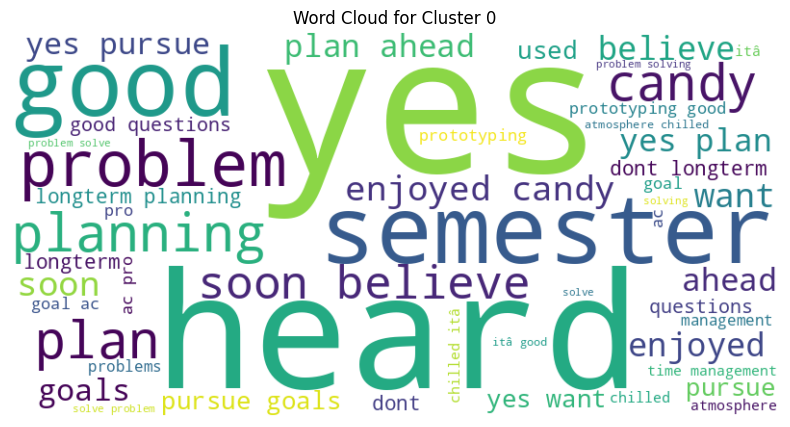

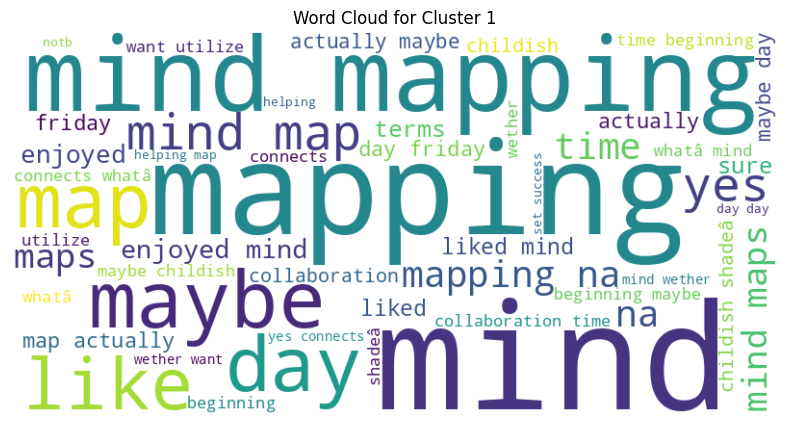

In [150]:
# Generate word clouds for each cluster

for i, center in enumerate(centroids):
    top_indices = center.argsort()[::-1]
    top_terms_weights = {terms[idx]: center[idx] for idx in top_indices[:50]}

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_terms_weights)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for Cluster {i}")
    plt.show()

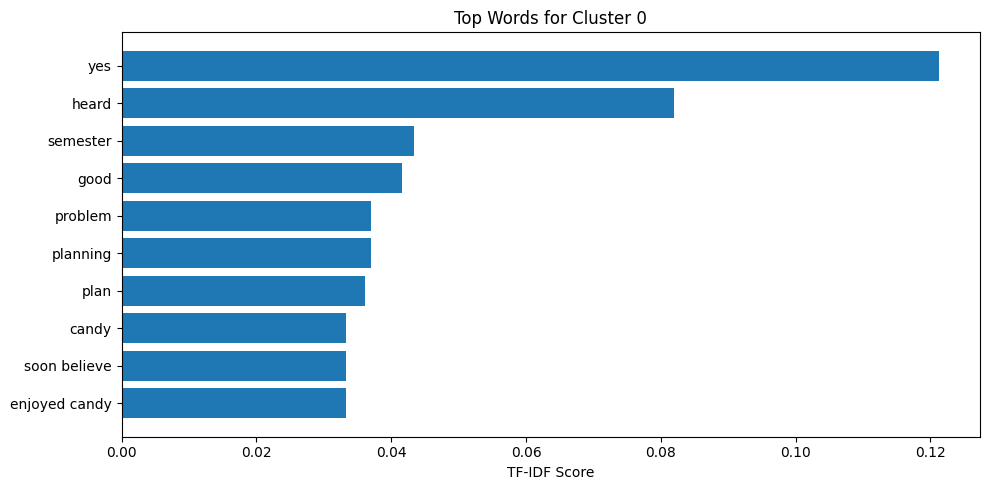

In [151]:
# Top Words for Cluster 0
cluster_id = 0  # change to 1 for the other cluster
top_indices = centroids[cluster_id].argsort()[::-1][:10]
top_words = [terms[i] for i in top_indices]
top_scores = centroids[cluster_id][top_indices]

plt.figure(figsize=(10, 5))
plt.barh(top_words[::-1], top_scores[::-1])
plt.title(f"Top Words for Cluster {cluster_id}")
plt.xlabel("TF-IDF Score")
plt.tight_layout()
plt.show()


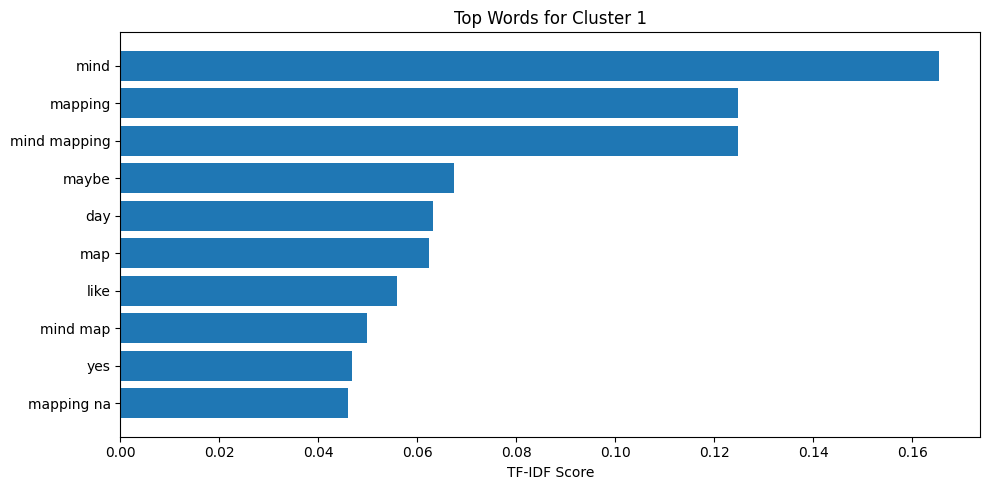

In [152]:
# Top Words for Cluster 1
cluster_id = 1  # change to 1 for the other cluster
top_indices = centroids[cluster_id].argsort()[::-1][:10]
top_words = [terms[i] for i in top_indices]
top_scores = centroids[cluster_id][top_indices]

plt.figure(figsize=(10, 5))
plt.barh(top_words[::-1], top_scores[::-1])
plt.title(f"Top Words for Cluster {cluster_id}")
plt.xlabel("TF-IDF Score")
plt.tight_layout()
plt.show()


In [153]:
# Re-apply preprocessing to create 'Cleaned_Text'
if 'Cleaned_Text' not in df.columns:
    texts_cleaned = df["Text"].astype(str).apply(preprocess) # Use clean_text instead of preprocess
    df["Cleaned_Text"] = texts_cleaned


# Vectorize with CountVectorizer instead of TF-IDF
count_vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X_counts = count_vectorizer.fit_transform(df["Cleaned_Text"])
terms = count_vectorizer.get_feature_names_out()

# Convert to DataFrame
counts_df = pd.DataFrame(X_counts.toarray(), columns=terms)
counts_df["Cluster"] = df["Cluster"]

# Sum word counts per cluster
cluster_word_counts = counts_df.groupby("Cluster").sum().T

# View top words in each cluster
top_words_with_counts = {}
for cluster_num in cluster_word_counts.columns:
    top_words = cluster_word_counts[cluster_num].sort_values(ascending=False).head(15)
    top_words_with_counts[f"Cluster {cluster_num}"] = top_words
    print(f"Top words in Cluster {cluster_num}:")
    print(top_words)
    print("\n")

Top words in Cluster 0:
yes           8
semester      4
heard         3
want          3
planning      2
problems      2
problem       2
management    2
plan          2
good          2
time          2
used          2
connection    1
created       1
ios           1
Name: 0, dtype: int64


Top words in Cluster 1:
mind           10
mapping         5
like            4
map             4
maybe           4
yes             4
time            3
day             3
sure            2
terms           2
liked           2
critical        1
controlling     1
connections     1
childish        1
Name: 1, dtype: int64




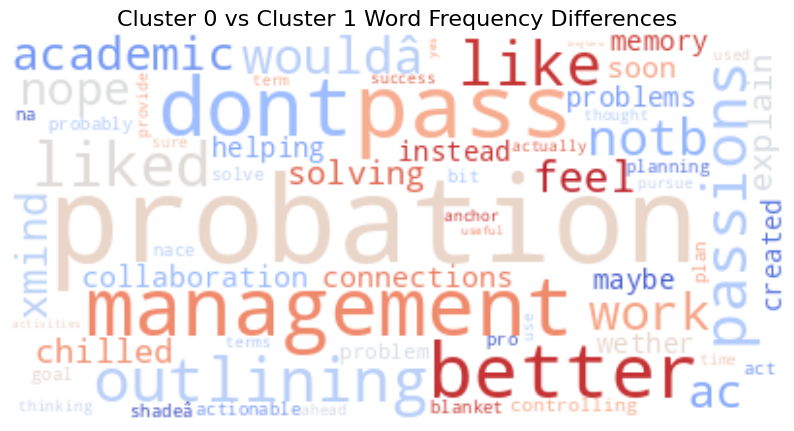

In [158]:
# Separate by cluster
df_cluster_0 = df[df["Cluster"] == 0]
df_cluster_1 = df[df["Cluster"] == 1]

X_0 = vectorizer.transform(df_cluster_0["Cleaned_Text"])
X_1 = vectorizer.transform(df_cluster_1["Cleaned_Text"])

# Get word frequencies per cluster
freq_dict_0 = dict(zip(terms, X_0.toarray().sum(axis=0)))
freq_dict_1 = dict(zip(terms, X_1.toarray().sum(axis=0)))

# Define and run your comparison
def compare_wordclouds(freq_dict1, freq_dict2, title="Word Cloud Comparison"):
    diff_dict = {}
    all_words = set(freq_dict1.keys()) | set(freq_dict2.keys())
    for word in all_words:
        diff_dict[word] = freq_dict1.get(word, 0) - freq_dict2.get(word, 0)

    wordcloud = WordCloud(width=400, height=200, background_color='white', colormap='coolwarm')
    wordcloud = wordcloud.generate_from_frequencies(diff_dict)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Visualize Combined Word Clouds
compare_wordclouds(freq_dict_0, freq_dict_1, title="Cluster 0 vs Cluster 1 Word Frequency Differences")


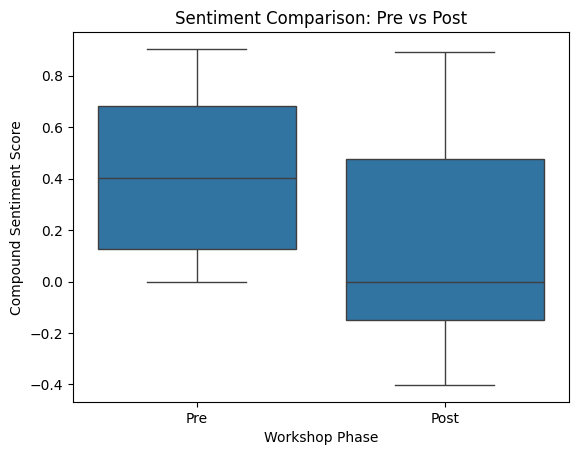

Label
Post    0.166573
Pre     0.430133
Name: sentiment, dtype: float64


In [157]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Apply sentiment scoring
df['sentiment'] = df['Cleaned_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Plot by label
sns.boxplot(x='Label', y='sentiment', data=df)
plt.title('Sentiment Comparison: Pre vs Post')
plt.ylabel('Compound Sentiment Score')
plt.xlabel('Workshop Phase')
plt.show()

# show average scores
print(df.groupby('Label')['sentiment'].mean())